In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amisha0528/mall-customers-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mall-customers-dataset' dataset.
Path to dataset files: /kaggle/input/mall-customers-dataset


In [ ]:
import os
print(os.listdir(path))

['Mall_Customers.csv']


In [ ]:
df=pd.read_csv(path+'/Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
X=df[["Annual Income (k$)","Spending Score (1-100)"]]

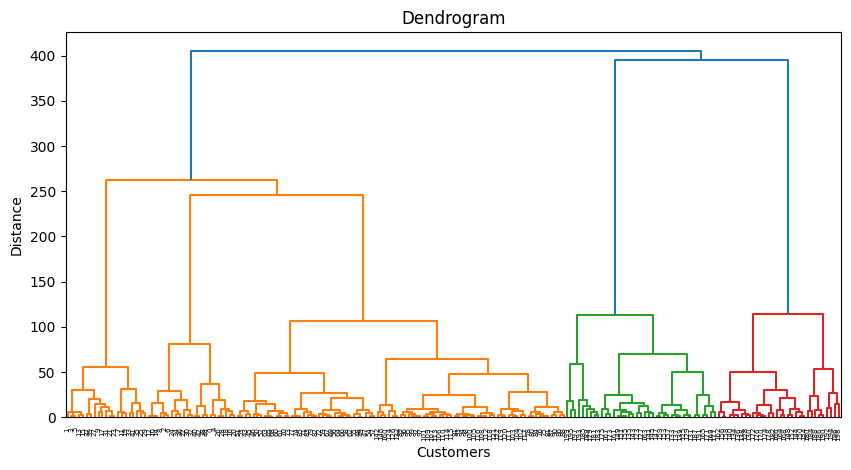

In [ ]:
from scipy.cluster.hierarchy import dendrogram,linkage
#Create dentogram
Z = linkage(X, method='ward')

plt.figure(figsize=(10,5))

dendrogram(Z)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2,21):

    hc = AgglomerativeClustering(
        n_clusters=k
    )

    clusters = hc.fit_predict(X)

    score = silhouette_score(X, clusters)

    print(f"K = {k}  -->  Silhouette Score = {score:.4f}")

    # so here K=5 is best value-0.5530

K = 2  -->  Silhouette Score = 0.3671
K = 3  -->  Silhouette Score = 0.4618
K = 4  -->  Silhouette Score = 0.4917
K = 5  -->  Silhouette Score = 0.5530
K = 6  -->  Silhouette Score = 0.5380
K = 7  -->  Silhouette Score = 0.5199
K = 8  -->  Silhouette Score = 0.4326
K = 9  -->  Silhouette Score = 0.4389
K = 10  -->  Silhouette Score = 0.4343
K = 11  -->  Silhouette Score = 0.4235
K = 12  -->  Silhouette Score = 0.4292
K = 13  -->  Silhouette Score = 0.4115
K = 14  -->  Silhouette Score = 0.4117
K = 15  -->  Silhouette Score = 0.4194
K = 16  -->  Silhouette Score = 0.4191
K = 17  -->  Silhouette Score = 0.4123
K = 18  -->  Silhouette Score = 0.4230
K = 19  -->  Silhouette Score = 0.4208
K = 20  -->  Silhouette Score = 0.4222


In [ ]:
from sklearn.cluster import AgglomerativeClustering
model=AgglomerativeClustering(n_clusters=5)
clusters=model.fit_predict(X)

##Visualize:

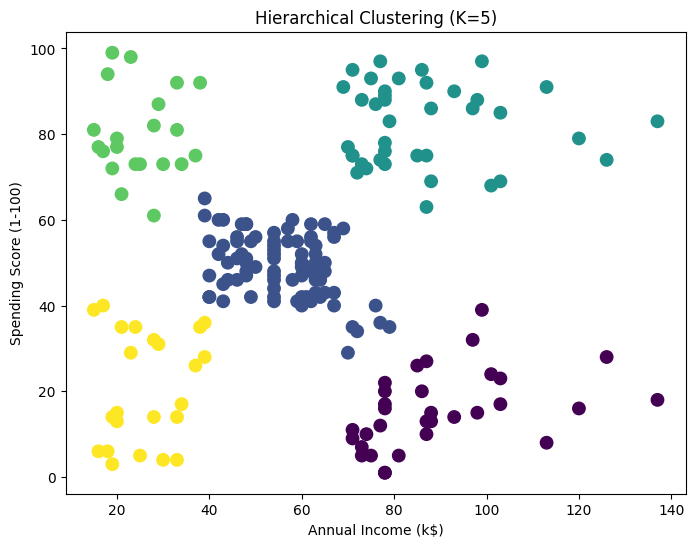

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=clusters,
    s=80

)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering (K=5)")
plt.show()

# Hierarchical Clustering

1. Start with each data point as its own cluster.
2. Merge the closest clusters repeatedly.
3. Build a Dendrogram.
4. Find the largest vertical gap.
5. Draw a horizontal cut.
6. Number of branches cut = K.
7. Train AgglomerativeClustering(n_clusters=K).
8. Evaluate using Silhouette Score.